In [251]:
import numpy as np
from typing import List, Dict, Any, Optional

# Tensor Engine

<img src="https://res.cloudinary.com/dnmobechs/image/upload/v1784963479/diagram-export-7-25-2026-12_39_58-PM_ilua6t.png" />

In [252]:
class Tensor:
    def __init__(self, data, parents=(), op=""):
        # Ensure data is a NumPy array, converting if necessary.
        if not isinstance(data, np.ndarray):
            data = np.array(data)
        # Store the data as a float32 NumPy array for consistency.
        self.data = data.astype(np.float32)
        # Initialize gradient with zeros, matching the shape of the data.
        self.grad = np.zeros_like(self.data)
        # Store the operation that created this tensor (e.g., '+', '*', '@').
        self.op = op
        # Keep track of parent tensors for building the computational graph.
        self.parents = parents
        # Initialize backward function, which will be set by operations.
        self._backward = lambda: None

    # String representation for easy printing of Tensor objects.
    def __repr__(self):
        return f"Tensor(shape={self.data.shape}, op='{self.op}')"

    # Defines element-wise addition for two tensors.
    def __add__(self, other):
        """
        Add two tensors elementwise.

        Example:
            a = Tensor([1, 2, 3])
            b = Tensor([4, 5, 6])
            c = a + b  # c.data = [5, 7, 9]

        Broadcasting:
            a = Tensor([[1, 2], [3, 4]])  # shape (2, 2)
            b = Tensor([10, 20])          # shape (2,)
            c = a + b  # b broadcasts to (2, 2)
                       # c = [[11, 22], [13, 24]]
        """
        # Convert 'other' to a Tensor if it's not already one.
        other = other if isinstance(other, Tensor) else Tensor(other)
        # Perform element-wise addition to get the output data.
        out = Tensor(
            self.data + other.data,
            # Link parent tensors for backpropagation.
            parents=(self, other),
            op="+"
        )

        # Define the backward pass for addition.
        def _backward():
            # If 'self' was broadcasted during the forward pass, sum gradients over the broadcasted axes.
            if self.data.shape != out.grad.shape:
                self.grad += self._sum_broadcast(out.grad, self.data.shape)
            else:
                self.grad += out.grad # Otherwise, directly add the output gradient.
            # If 'other' was broadcasted during the forward pass, sum gradients over the broadcasted axes.
            if other.data.shape != out.grad.shape:
                other.grad += self._sum_broadcast(out.grad, other.data.shape)
            else:
                other.grad += out.grad # Otherwise, directly add the output gradient.

        out._backward = _backward
        return out

    # Defines element-wise subtraction for two tensors.
    def __sub__(self, other):
        """
        Subtract two tensors elementwise.

        Example:
            a = Tensor([1, 2, 3])
            b = Tensor([4, 5, 6])
            c = a - b  # c.data = [-3, -3, -3]

        Gradient: d(a-b)/da = 1, d(a-b)/db = -1
        """
        # Convert 'other' to a Tensor if it's not already one.
        other = other if isinstance(other, Tensor) else Tensor(other)

        # Perform element-wise subtraction.
        out = Tensor(
            self.data - other.data,
            parents=(self, other),
            op="-"
        )

        # Define the backward pass for subtraction.
        def _backward():
            # dL/da = dL/d(a-b) * 1
            if self.data.shape != out.grad.shape:
                self.grad += self._sum_broadcast(out.grad, self.data.shape)
            else:
                self.grad += out.grad

            # dL/db = dL/d(a-b) * -1
            if other.data.shape != out.grad.shape:
                other.grad += self._sum_broadcast(-out.grad, other.data.shape)
            else:
                other.grad += -out.grad

        out._backward = _backward
        return out

    # Defines element-wise division for two tensors.
    def __truediv__(self, other):
        """
        Divide two tensors elementwise.

        Example:
            a = Tensor([1, 2, 3])
            b = Tensor([2, 2, 2])
            c = a / b  # c.data = [0.5, 1.0, 1.5]

        Gradient: d(a/b)/da = 1/b, d(a/b)/db = -a/b^2
        """
        # Convert 'other' to a Tensor if it's not already one.
        other = other if isinstance(other, Tensor) else Tensor(other)

        # Perform element-wise division.
        out = Tensor(
            self.data / other.data,
            parents=(self, other),
            op="/"
        )

        # Define the backward pass for division.
        def _backward():
            # dL/da = dL/d(a/b) * (1/b)
            self_grad = out.grad * (1 / other.data)
            if self.data.shape != self_grad.shape:
                self.grad += self._sum_broadcast(self_grad, self.data.shape)
            else:
                self.grad += self_grad

            # dL/db = dL/d(a/b) * (-a/b^2)
            # Ensure no division by zero when calculating other_grad
            # A small epsilon could be added if b.data can be zero
            other_grad = out.grad * (-self.data / (other.data**2 + 1e-8)) # Added epsilon for stability
            if other.data.shape != other_grad.shape:
                other.grad += self._sum_broadcast(other_grad, other.data.shape)
            else:
                other.grad += other_grad

        out._backward = _backward
        return out

    # Helper function to correctly sum gradients over broadcasted dimensions.
    def _sum_broadcast(self, grad, target_shape):
        if grad.shape == target_shape:
            return grad # No broadcasting occurred, return gradient as is.

        ndims = len(grad.shape)
        # Pad the target shape with 1s to match the number of dimensions of the gradient for comparison.
        target_padded = (1,) * (ndims - len(target_shape)) + target_shape

        axes_to_sum = []
        # Identify axes along which broadcasting occurred (where dimensions don't match).
        for i, (g_dim, t_dim) in enumerate(zip(grad.shape, target_padded)):
            if g_dim != t_dim:
                axes_to_sum.append(i)

        # If broadcasted axes are found, sum the gradient along these axes.
        if axes_to_sum:
            grad = grad.sum(axis=tuple(axes_to_sum), keepdims=False)

        # Reshape the gradient to match the target shape.
        return grad.reshape(target_shape)

    # Defines element-wise multiplication for two tensors.
    def __mul__(self, other):
        """
        Multiply two tensors elementwise.

        Example:
            a = Tensor([1, 2, 3])
            b = Tensor([4, 5, 6])
            c = a * b  # c.data = [4, 10, 18]

        Gradient: d(a*b)/da = b, d(a*b)/db = a
        """
        # Convert 'other' to a Tensor if it's not already one.
        other = other if isinstance(other, Tensor) else Tensor(other)

        # Perform element-wise multiplication.
        out = Tensor(
            self.data * other.data,
            parents=(self, other),
            op="*"
        )

        # Define the backward pass for multiplication.
        def _backward():
            # Gradient of multiplication:
            # dL/da = dL/d(a*b) * b
            # dL/db = dL/d(a*b) * a

            # Calculate gradient for 'self'.
            self_grad = out.grad * other.data
            # Apply sum_broadcast if 'self' was broadcasted.
            if self.data.shape != self_grad.shape:
                self.grad += self._sum_broadcast(self_grad, self.data.shape)
            else:
                self.grad += self_grad

            # Calculate gradient for 'other'.
            other_grad = out.grad * self.data
            # Apply sum_broadcast if 'other' was broadcasted.
            if other.data.shape != other_grad.shape:
                other.grad += self._sum_broadcast(other_grad, other.data.shape)
            else:
                other.grad += other_grad

        out._backward = _backward
        return out

    # Defines matrix multiplication for two tensors.
    def __matmul__(self, other):
        """
        Matrix multiplication: self @ other

        Forward: C = A @ B
        - A.shape = (batch, in_features)
        - B.shape = (in_features, out_features)
        - C.shape = (batch, out_features)

        Backward:
        - dC/dA = dC @ B.T
        - dC/dB = A.T @ dC

        Important: The gradients use matrix multiplication with transposes!
        """
        # Convert 'other' to a Tensor if it's not already one.
        other = other if isinstance(other, Tensor) else Tensor(other)

        # Forward pass: perform matrix multiplication.
        out = Tensor(
            self.data @ other.data,
            parents=(self, other),
            op="@"
        )

        # Define the backward pass for matrix multiplication.
        def _backward():
            # Gradient with respect to self (A):
            # If C = A @ B, then dL/dA = dL/dC @ B.T (where dL/dC is out.grad)
            self_grad = out.grad @ other.data.T

            # Handle potential broadcasting (though less common in explicit matmul).
            if self.data.shape != self_grad.shape:
                self.grad += self._sum_broadcast(self_grad, self.data.shape)
            else:
                self.grad += self_grad

            # Gradient with respect to other (B):
            # If C = A @ B, then dL/dB = A.T @ dL/dC
            other_grad = self.data.T @ out.grad

            # Handle potential broadcasting.
            if other.data.shape != other_grad.shape:
                other.grad += self._sum_broadcast(other_grad, other.data.shape)
            else:
                other.grad += other_grad

        out._backward = _backward
        return out

    # Reduces the tensor to a scalar by summing all its elements.
    def sum(self):
      # Create a new Tensor with the sum of data and link 'self' as a parent.
      out = Tensor(self.data.sum(), parents=(self,))
      # Define the backward pass for the sum operation.
      def _backward():
        # The gradient of sum is simply the gradient of the output propagated to all elements, scaled by ones.
        self.grad += np.ones_like(self.data) * out.grad
      out._backward = _backward
      return out


    # Initiates the backpropagation process to compute gradients.
    def backward(self):
        # Initialize data structures for topological sort.
        topo = []
        visited = set()

        # Helper function to build the topological order of the computational graph.
        def build_topo(v):
            """Recursively collect all nodes in the graph in topological order."""
            if v not in visited:
                visited.add(v)
                for p in v.parents:
                    build_topo(p)
                topo.append(v)

        # Start building the graph from the current tensor.
        build_topo(self)

        # Initialize the gradient of the output tensor (dL/dL = 1).
        # For a scalar output, grad is 1.0; for a vector/matrix, it's ones_like.
        if self.data.size == 1:
            self.grad = np.array([1.0])
        else:
            self.grad = np.ones_like(self.data)

        # Iterate through the graph in reverse topological order and call each tensor's _backward method.
        for v in reversed(topo):
            v._backward()

        #print(f"Backward complete! Processed {len(topo)} nodes.")

# Custom Module

<img src="https://res.cloudinary.com/dnmobechs/image/upload/v1784966332/ChatGPT_Image_Jul_25_2026_01_25_17_PM_qf3jrf.png" />

In [253]:
class Module:
  def __init__(self):
    self._parameters: Dict[str, 'Tensor'] = {}
    self._modules: Dict[str, 'Module'] = {}
    self.training: bool = True

  def __setattr__(self, name: str, value: Any):
    if isinstance(value, Tensor):
        self._parameters[name] = value
    elif isinstance(value, Module):
        self._modules[name] = value
    super().__setattr__(name, value)

  def parameters(self) -> List['Tensor']:
    params = []
    for param in self._parameters.values():
      params.append(param)
    for module in self._modules.values():
      params += module.parameters()
    return params

  def zero_grad(self):
    for param in self.parameters():
        param.grad = np.zeros_like(param.data)

  def forward(self, x: 'Tensor') -> 'Tensor':
    raise NotImplementedError("Subclasses must implement forward()")

  def backward(self):
    raise NotImplementedError

  def __call__(self, *args, **kwargs) -> 'Tensor': # Modified to accept multiple args/kwargs
    return self.forward(*args, **kwargs)


In [254]:
print("Testing Module Class")

# A simple custom module

class TestModule(Module):
    def __init__(self):
        super().__init__()

        # Learnable parameters
        self.weight = Tensor(np.random.randn(3, 2))
        self.bias = Tensor(np.random.randn(2))

        # Child module (used only to test automatic registration)
        self.sub = Module()

    def forward(self, x):
        return x @ self.weight + self.bias

# Create the module
model = TestModule()

# Check automatic parameter registration
print("\nRegistered Parameters")
for name, tensor in model._parameters.items():
    print(f"{name:<10} shape = {tensor.data.shape}")

# Check submodule registration
print("\nRegistered Submodules")

for name, module in model._modules.items():
    print(f"{name:<10} -> {module.__class__.__name__}")

# Recursive parameter collection
params = model.parameters()

print("\nTotal Parameters")
print(f"Found {len(params)} parameter tensors")

# Initial gradients
print("\nInitial Gradients")
for i, param in enumerate(params, start=1):
    print(f"Parameter {i}: grad sum = {param.grad.sum():.4f}")

# Assign random gradients
print("\nAssigning Random Gradients...")
for param in params:
    param.grad = np.random.randn(*param.data.shape)


print("\nRandom Gradients")
for i, param in enumerate(params, start=1):
    print(f"Parameter {i}: grad sum = {param.grad.sum():.4f}")

# Reset gradients
print("\nCalling model.zero_grad()...")
model.zero_grad()

print("\nGradients After zero_grad()")

for i, param in enumerate(params, start=1):
    print(f"Parameter {i}: grad sum = {param.grad.sum():.4f}")

print("\n✓ Module class is working correctly!")

Testing Module Class

Registered Parameters
weight     shape = (3, 2)
bias       shape = (2,)

Registered Submodules
sub        -> Module

Total Parameters
Found 2 parameter tensors

Initial Gradients
Parameter 1: grad sum = 0.0000
Parameter 2: grad sum = 0.0000

Assigning Random Gradients...

Random Gradients
Parameter 1: grad sum = -3.3949
Parameter 2: grad sum = 1.5018

Calling model.zero_grad()...

Gradients After zero_grad()
Parameter 1: grad sum = 0.0000
Parameter 2: grad sum = 0.0000

✓ Module class is working correctly!


# Weight Initialization Functions

Neural networks perform much better when weights are initialized carefully instead of randomly.

In this section, we'll implement a few common initialization methods used in deep learning.

### Initializers

- **Xavier (Glorot) Uniform**
  - Best for sigmoid and tanh activations.
  - Keeps the variance of activations stable across layers.

- **Kaiming (He) Uniform**
  - Designed for ReLU-based networks.
  - Helps prevent vanishing activations in deep models.

- **Zeros Initializer**
  - Creates tensors filled with zeros.
  - Commonly used for initializing bias vectors.

- **Ones Initializer**
  - Creates tensors filled with ones.
  - Useful for testing and certain normalization layers.

In [255]:
import math

def xavier_uniform(fan_in, fan_out, gain=1.0):
  limit = gain * math.sqrt(6 / (fan_in + fan_out))
  return np.random.uniform(-limit, limit, size=(fan_in, fan_out))

def kaiming_uniform(fan_in, fan_out, gain=1.0):
  limit = gain * math.sqrt(3 / fan_in)
  return np.random.uniform(-limit, limit, size=(fan_in, fan_out))

def zeros_initializer(shape):
    return np.zeros(shape)

def ones_initializer(shape):
    return np.ones(shape)

# Linear Forward Module

<img src="https://res.cloudinary.com/dnmobechs/image/upload/v1784978108/diagram-export-7-25-2026-4_44_50-PM_ilmqeb.png" />

In [256]:
class Linear(Module):
    """
    Applies a linear transformation: y = x @ W + b

    Args:
        in_features: Size of each input sample
        out_features: Size of each output sample
        bias: If True, adds a learnable bias
        initialization: 'xavier', 'kaiming', or 'zeros'
    """

    def __init__(self, in_features, out_features, bias=True, initialization='xavier'):
        super().__init__()

        # Save layer configuration
        self.in_features = in_features
        self.out_features = out_features
        self.use_bias = bias

        # Validate input dimensions
        if in_features <= 0 or out_features <= 0:
            raise ValueError(f"Features must be positive: in={in_features}, out={out_features}")

        # Initialize weights
        if initialization == 'xavier':
            weight_data = xavier_uniform(in_features, out_features)
        elif initialization == 'kaiming':
            weight_data = kaiming_uniform(in_features, out_features)
        elif initialization == 'zeros':
            weight_data = zeros_initializer((in_features, out_features))
        else:
            raise ValueError(f"Unknown initialization: {initialization}")

        # Create weight tensor
        self.weight = Tensor(weight_data)

        # Initialize bias (if used)
        if bias:
            # Bias is usually initialized to zeros
            self.bias = Tensor(np.zeros(out_features))
        else:
            self.bias = None

        # We're done - __setattr__ in Module will track these automatically

    def forward(self, x: Tensor) -> Tensor:
        """
        Forward pass: y = x @ weight + bias

        Shape check:
            x: (batch_size, in_features)
            weight: (in_features, out_features)
            bias: (out_features,)
            y: (batch_size, out_features)
        """
        # Validate input shape
        if len(x.data.shape) != 2:
            raise ValueError(f"Expected 2D input (batch, features), got {len(x.data.shape)}D")

        if x.data.shape[1] != self.in_features:
            raise ValueError(f"Expected {self.in_features} features, got {x.data.shape[1]}")

        # Matrix multiplication
        y = x @ self.weight

        # Add bias if present (broadcasting handles the batch dimension)
        if self.use_bias:
            y = y + self.bias

        return y

    def __repr__(self):
        return f"Linear(in_features={self.in_features}, out_features={self.out_features}, bias={self.use_bias})"

In [257]:
print("Testing My Linear Layer")

# Create a Linear layer
linear = Linear(
    in_features=5,
    out_features=3,
    bias=True,
    initialization="xavier"
)

print("\nLinear layer created successfully!")
print(f"Weight shape : {linear.weight.data.shape}")
print(f"Bias shape   : {linear.bias.data.shape}")

# Random input (4 samples, each having 5 features)
x = Tensor(np.random.randn(4, 5))
print(f"\nInput shape  : {x.data.shape}")

# Forward pass
output = linear(x)
print(f"Output shape : {output.data.shape}")

# Check output dimensions
assert output.data.shape == (4, 3), "Output shape is incorrect!"
print("Output shape is correct.")

# Check Xavier initialization
actual_std = linear.weight.data.std()
expected_std = math.sqrt(2 / (5 + 3))

print("\nWeight Initialization")
print(f"Mean         : {linear.weight.data.mean():.6f}")
print(f"Actual Std   : {actual_std:.6f}")
print(f"Expected Std : {expected_std:.6f}")

if abs(actual_std - expected_std) < 0.2:
    print("Xavier initialization looks good.")
else:
    print("Weight initialization may need checking.")

# Bias should start from zeros
print("\nBias Check")
print(f"Mean : {linear.bias.data.mean():.6f}")
print(f"Std  : {linear.bias.data.std():.6f}")

if np.allclose(linear.bias.data, 0):
    print("Bias initialized correctly (all zeros).")
else:
    print("Bias initialization is incorrect.")

print("\nAll tests completed successfully!")

Testing My Linear Layer

Linear layer created successfully!
Weight shape : (5, 3)
Bias shape   : (3,)

Input shape  : (4, 5)
Output shape : (4, 3)
Output shape is correct.

Weight Initialization
Mean         : -0.102187
Actual Std   : 0.522673
Expected Std : 0.500000
Xavier initialization looks good.

Bias Check
Mean : 0.000000
Std  : 0.000000
Bias initialized correctly (all zeros).

All tests completed successfully!


In [258]:
print("Testing Gradient Flow")

# Create a Linear layer
linear = Linear(in_features=3, out_features=2, bias=True)

# Random input (2 samples, 3 features each)
x = Tensor(np.random.randn(2, 3))

# Forward pass
output = linear(x)
loss = output.sum()

print(f"\nInput shape  : {x.data.shape}")
print(f"Output shape : {output.data.shape}")
print(f"Loss value   : {loss.data}")

# Backward pass
loss.backward()

print("\nGradient Check")
print(f"Weight grad shape : {linear.weight.grad.shape}")
print(f"Weight grad mean  : {linear.weight.grad.mean():.6f}")
print(f"Weight grad sum   : {linear.weight.grad.sum():.6f}")

if linear.use_bias:
    print(f"\nBias grad shape   : {linear.bias.grad.shape}")
    print(f"Bias grad mean    : {linear.bias.grad.mean():.6f}")
    print(f"Bias grad sum     : {linear.bias.grad.sum():.6f}")

# Make sure gradients were computed
assert not np.allclose(linear.weight.grad, 0), "Weight gradients should not be zero."

if linear.use_bias:
    assert not np.allclose(linear.bias.grad, 0), "Bias gradients should not be zero."

print("\nGradient computation is working correctly.")

# Reset gradients
linear.zero_grad()

print("\nAfter calling zero_grad()")
print(f"Weight grad sum : {linear.weight.grad.sum():.6f}")

if linear.use_bias:
    print(f"Bias grad sum   : {linear.bias.grad.sum():.6f}")

assert np.allclose(linear.weight.grad, 0)

if linear.use_bias:
    assert np.allclose(linear.bias.grad, 0)

print("All gradients have been reset successfully.")

Testing Gradient Flow

Input shape  : (2, 3)
Output shape : (2, 2)
Loss value   : 1.4922198057174683

Gradient Check
Weight grad shape : (3, 2)
Weight grad mean  : -0.361433
Weight grad sum   : -2.168599

Bias grad shape   : (2,)
Bias grad mean    : 2.000000
Bias grad sum     : 4.000000

Gradient computation is working correctly.

After calling zero_grad()
Weight grad sum : 0.000000
Bias grad sum   : 0.000000
All gradients have been reset successfully.


# Activation Layers

Each activation layer inherits from `Module`, performs a forward computation, creates an output `Tensor`, and defines its own `_backward()` function so gradients can flow correctly during backpropagation.

In [259]:
class ReLU(Module):
    """
    Applies the Rectified Linear Unit function: max(0, x)
    Gradient: 1 if x > 0 else 0
    """
    def forward(self, x: Tensor) -> Tensor:
        # Create a copy of the input data
        data = x.data.copy()

        # Apply ReLU: set negative values to 0
        data[data < 0] = 0

        # Create output tensor (for gradient tracking)
        out = Tensor(data, parents=(x,), op="relu")

        def _backward():
            # Gradient of ReLU: 1 for positive, 0 for negative
            grad = out.grad.copy()
            grad[x.data <= 0] = 0  # Zero out gradients where input was <= 0
            x.grad += grad

        out._backward = _backward
        return out

    def __repr__(self):
        return "ReLU()"

class Tanh(Module):
    """
    Applies the hyperbolic tangent function: tanh(x)
    Gradient: 1 - tanh(x)^2
    """
    def forward(self, x: Tensor) -> Tensor:
        data = np.tanh(x.data)
        out = Tensor(data, parents=(x,), op="tanh")

        def _backward():
            grad = out.grad * (1 - data**2)
            x.grad += grad

        out._backward = _backward
        return out

    def __repr__(self):
        return "Tanh()"

class Sigmoid(Module):
    """
    Applies the sigmoid function: 1/(1+exp(-x))
    Gradient: sigmoid(x) * (1 - sigmoid(x))
    """
    def forward(self, x: Tensor) -> Tensor:
        data = 1 / (1 + np.exp(-np.clip(x.data, -500, 500)))
        out = Tensor(data, parents=(x,), op="sigmoid")

        def _backward():
            grad = out.grad * data * (1 - data)
            x.grad += grad

        out._backward = _backward
        return out

    def __repr__(self):
        return "Sigmoid()"

class Softmax(Module):
    """
    Applies the softmax function: exp(x_i) / sum(exp(x_j))
    """
    def forward(self, x: Tensor) -> Tensor:
        shifted = x.data - np.max(x.data, axis=-1, keepdims=True)
        exp_vals = np.exp(shifted)
        probs = exp_vals / np.sum(exp_vals, axis=-1, keepdims=True)

        out = Tensor(probs, parents=(x,), op="softmax")

        def _backward():
            grad_output = out.grad
            p = out.data
            # Sum over the class dimension for each sample
            sum_p_grad = np.sum(p * grad_output, axis=-1, keepdims=True)
            grad_input = p * (grad_output - sum_p_grad)
            x.grad += grad_input

        out._backward = _backward
        return out

    def __repr__(self):
        return "Softmax()"


Testing ReLU()


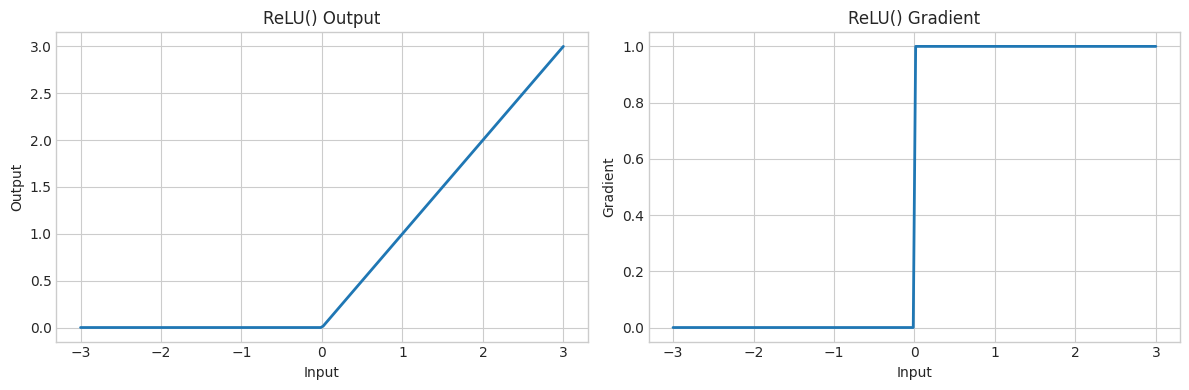


Testing Tanh()


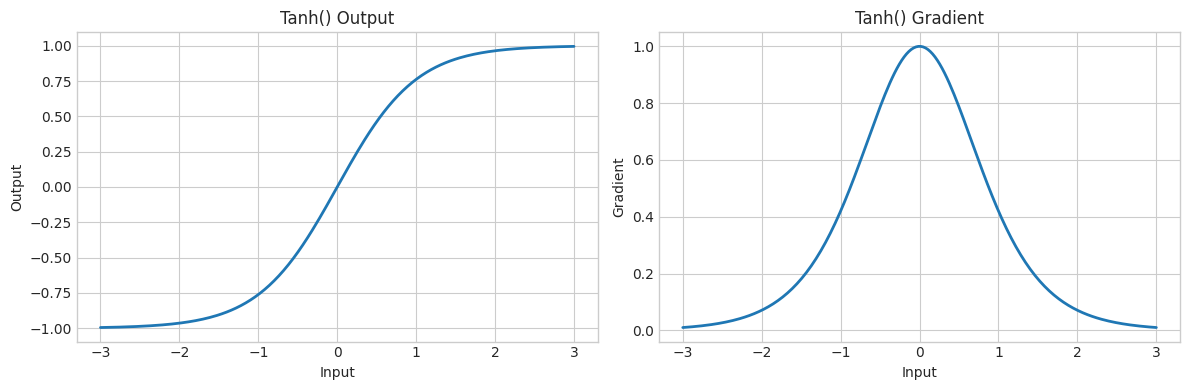


Testing Sigmoid()


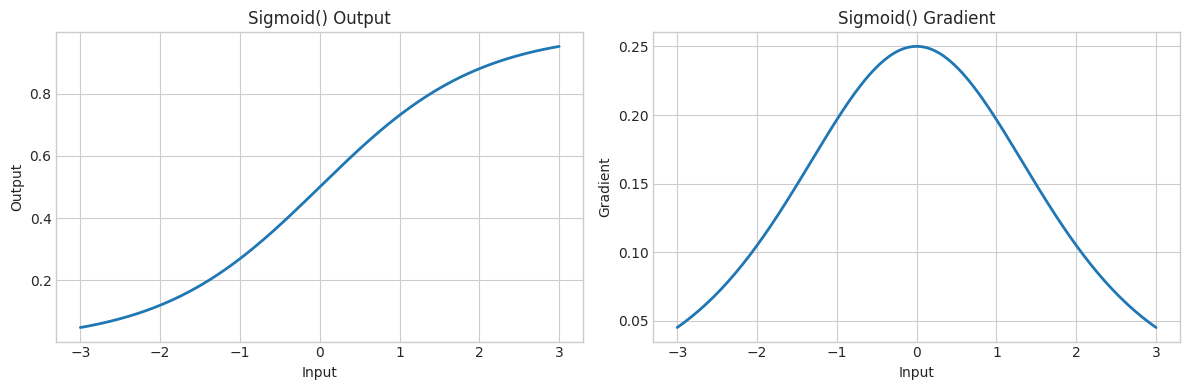


Testing Softmax

Input:
[[ 0.5  1.   0. ]
 [-0.5  2.   1.5]]

Output Probabilities:
[[0.3071959  0.5064804  0.18632372]
 [0.04861083 0.59220105 0.3591881 ]]

Sum of each row:
[1. 1.]


In [260]:
import matplotlib.pyplot as plt
import numpy as np

def plot_activation(module, name, x_range=(-3, 3)):

    # Sample input values
    x_values = np.linspace(x_range[0], x_range[1], 200)
    # Forward pass
    x = Tensor(x_values.reshape(-1, 1))
    output = module(x)
    # Backward pass
    output.grad = np.ones_like(output.data)
    output._backward()
    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))

    # Activation curve
    ax[0].plot(x_values, output.data.flatten(), linewidth=2)
    ax[0].set_title(f"{name} Output")
    ax[0].set_xlabel("Input")
    ax[0].set_ylabel("Output")
    ax[0].grid(True)

    # Gradient curve
    ax[1].plot(x_values, x.grad.flatten(), linewidth=2)
    ax[1].set_title(f"{name} Gradient")
    ax[1].set_xlabel("Input")
    ax[1].set_ylabel("Gradient")
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()

# Test ReLU, Tanh and Sigmoid
for activation in [ReLU(), Tanh(), Sigmoid()]:
    print(f"\nTesting {activation}")
    plot_activation(activation, str(activation))

# Softmax example
print("\nTesting Softmax")

sample = Tensor(np.array([
    [0.5, 1.0, 0.0],
    [-0.5, 2.0, 1.5]
]))

softmax = Softmax()
probabilities = softmax(sample)

print("\nInput:")
print(sample.data)

print("\nOutput Probabilities:")
print(probabilities.data)

print("\nSum of each row:")
print(probabilities.data.sum(axis=1))

# Sequential Layer

This cell implements the `Sequential` container, which combines multiple layers into a single model. Instead of calling each layer manually, the input automatically passes through every layer in order.


In [261]:
class Sequential(Module):
    """
    Example:
        model = Sequential(
            Linear(10, 20),
            ReLU(),
            Linear(20, 5),
            Softmax()
        )
        output = model(input)  # input passes through each layer in order
    """

    def __init__(self, *layers):
        super().__init__()
        # Store layers in a list
        self.layers = []

        # Add each layer as a submodule for parameter tracking
        for i, layer in enumerate(layers):
            name = f"layer_{i}"
            setattr(self, name, layer)
            self.layers.append(layer)

    def forward(self, x: Tensor) -> Tensor:
        """Pass input through each layer sequentially."""
        for layer in self.layers:
            x = layer(x)
        return x

    def __repr__(self):
        layer_reprs = [str(layer) for layer in self.layers]
        return f"Sequential(\n  " + "\n  ".join(layer_reprs) + "\n)"

    def __getitem__(self, idx):
        """Allow indexing: model[0] returns first layer"""
        return self.layers[idx]

    def __len__(self):
        return len(self.layers)

In [262]:
"""
This script demonstrates a complete forward and backward pass through a 3-layer neural network.
"""

import numpy as np

model = Sequential(
    Linear(4, 8, initialization='kaiming'),
    Tanh(),
    Linear(8, 4, initialization='kaiming'),
    Tanh(),
    Linear(4, 4, initialization='kaiming')
)

print(f"Model structure:\n{model}\n")

# Sum up all weights and biases in the network
total_params = 0
for param in model.parameters():
    total_params += param.data.size

print(f"Total trainable parameters: {total_params}")

# Create a batch of 3 random samples, each with 4 features
batch_size = 3
x = Tensor(np.random.randn(batch_size, 4))
print(f"Input shape: {x.data.shape}")

# Pass data through the network to get predictions
y = model(x)
print(f"Output shape: {y.data.shape}")

print(f"Output (logits before Softmax if it were present):\n{y.data}")

# Sum all outputs to create a single loss value
loss = y.sum()
print(f"\nLoss (sum of outputs): {loss.data:.6f}")

# Propagate the loss backwards through the network
loss.backward()

print("\nGradient check (non-zero for all?):")
all_nonzero = True

for i, param in enumerate(model.parameters()):
    # Calculate gradient magnitude using L2 norm
    grad_norm = np.linalg.norm(param.grad)

    # Check if gradient is significant (above machine epsilon threshold)
    is_nonzero = grad_norm > 1e-8

    print(f"  Parameter {i}: shape={param.data.shape}, "
          f"grad_norm={grad_norm:.6f}, non-zero? {is_nonzero}")

    if not is_nonzero:
        all_nonzero = False

# With Tanh and sum loss, all gradients should be non-zero (expected behavior)
if all_nonzero:
    print("\n✅ All parameters have non-zero gradients (good!) - "
          "Expected with Tanh activations and sum loss")
else:
    print("\n❌ Some parameters have zero gradients (unexpected!) - "
          "Check backpropagation logic")

Model structure:
Sequential(
  Linear(in_features=4, out_features=8, bias=True)
  Tanh()
  Linear(in_features=8, out_features=4, bias=True)
  Tanh()
  Linear(in_features=4, out_features=4, bias=True)
)

Total trainable parameters: 96
Input shape: (3, 4)
Output shape: (3, 4)
Output (logits before Softmax if it were present):
[[ 0.63218313  0.08112592 -0.18953614  0.4074832 ]
 [-0.15752932 -0.06718066  0.00551465 -0.3418972 ]
 [-0.97376764 -0.30684617  0.391004    0.5288501 ]]

Loss (sum of outputs): 0.009404

Gradient check (non-zero for all?):
  Parameter 0: shape=(4, 8), grad_norm=1.758615, non-zero? True
  Parameter 1: shape=(8,), grad_norm=2.412518, non-zero? True
  Parameter 2: shape=(8, 4), grad_norm=2.456983, non-zero? True
  Parameter 3: shape=(4,), grad_norm=6.535220, non-zero? True
  Parameter 4: shape=(4, 4), grad_norm=1.852995, non-zero? True
  Parameter 5: shape=(4,), grad_norm=6.000000, non-zero? True

✅ All parameters have non-zero gradients (good!) - Expected with Tanh a

# Loss Functions

In [263]:
class MSELoss(Module):
    """
    Mean Squared Error loss: (y_pred - y_true)^2
    """
    def forward(self, pred: Tensor, target: Tensor) -> Tensor:
        # Ensure same shape
        assert pred.data.shape == target.data.shape, f"Shape mismatch: {pred.data.shape} vs {target.data.shape}"
        # Compute squared differences
        diff = pred - target
        loss = (diff * diff).sum() / pred.data.size  # mean
        return loss

class CrossEntropyLoss(Module):
    """
    Cross Entropy loss for multi-class classification.

    Input: logits (unnormalized scores) from the network.
    Target: integer class indices (0 to num_classes-1).

    Formula: -log(p_target) where p_target is the softmax probability for the correct class.
    """
    def forward(self, logits: Tensor, targets: Tensor) -> Tensor:
        # Convert targets to numpy if not already
        if not isinstance(targets, Tensor):
            targets = Tensor(targets)
        # Softmax to get probabilities
        probs = Softmax()(logits)
        # Select the probabilities for the correct classes
        batch_size = logits.data.shape[0]
        target_indices = targets.data.astype(int)
        correct_probs = probs.data[np.arange(batch_size), target_indices]
        # Compute loss = -log(prob) for each sample, then mean
        loss = -np.log(correct_probs + 1e-8)
        loss = loss.mean()
        out = Tensor(loss, parents=(logits,), op="cross_entropy")

        def _backward():
            # Gradient of cross-entropy with softmax: grad = probs - one_hot(targets)
            # This is a known result: dL/dlogits = softmax(logits) - one_hot(targets)
            batch_size = logits.data.shape[0]
            grad = probs.data.copy()
            # For each sample, subtract 1 from the correct class index
            grad[np.arange(batch_size), target_indices] -= 1
            grad = grad / batch_size
            logits.grad += grad

        out._backward = _backward
        return out

# Optimizer: SGD (Stochastic Gradient Descent)

### Purpose
Updates neural network parameters by moving them in the direction that reduces loss, using the computed gradients.

### Update Rule
`param = param - learning_rate * gradient`

In [264]:
class SGD:
    """
    Stochastic Gradient Descent optimizer.
    Updates: param.data -= learning_rate * param.grad
    """
    def __init__(self, parameters, learning_rate=0.01):
        self.parameters = list(parameters)
        self.lr = learning_rate

    def step(self):
        """Update all parameters."""
        for param in self.parameters:
            param.data -= self.lr * param.grad

    def zero_grad(self):
        """Zero gradients of all parameters."""
        for param in self.parameters:
            param.grad = np.zeros_like(param.data)

# Training Final Neural Networks from Scratch

Dataset shape:
  X: (200, 2)
  y: (200,)

--- Training with MSE ---
Epoch 25/100, Loss: 0.082670
Epoch 50/100, Loss: 0.074192
Epoch 75/100, Loss: 0.069557
Epoch 100/100, Loss: 0.065711


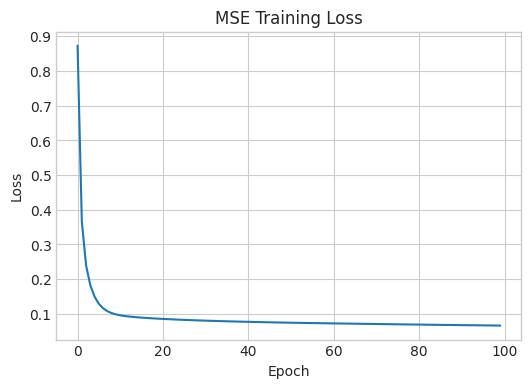


--- Training with CrossEntropy ---
Epoch 25/100, Loss: 0.292691
Epoch 50/100, Loss: 0.215088
Epoch 75/100, Loss: 0.188603
Epoch 100/100, Loss: 0.176131


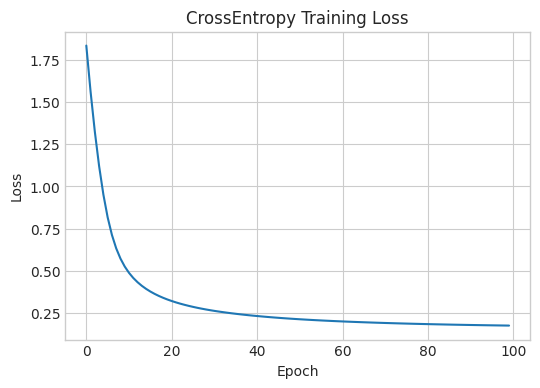


Final Training accuracy: 0.9300


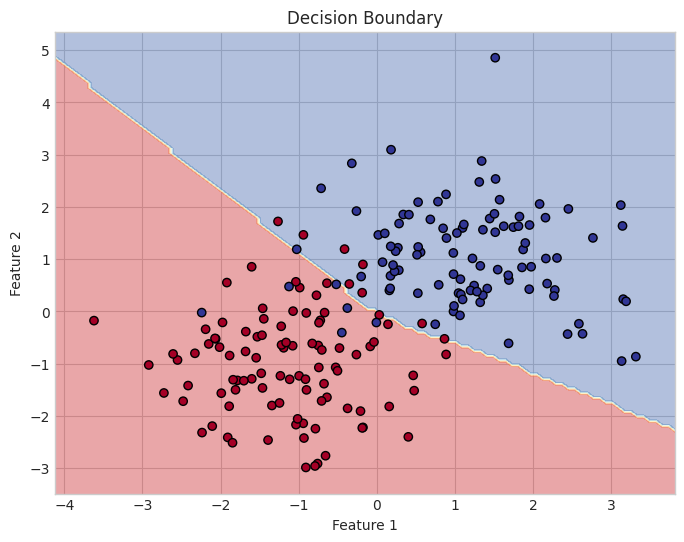

In [265]:
np.random.seed(42)
num_samples = 200
num_features = 2

X0 = np.random.randn(num_samples//2, num_features) + np.array([-1, -1])
y0 = np.zeros(num_samples//2)

X1 = np.random.randn(num_samples//2, num_features) + np.array([1, 1])
y1 = np.ones(num_samples//2)

X = np.vstack([X0, X1])
y = np.hstack([y0, y1])
shuffle_idx = np.random.permutation(num_samples)
X = X[shuffle_idx]
y = y[shuffle_idx]

X_tensor = Tensor(X)
y_tensor = Tensor(y.reshape(-1, 1))  # For MSE loss
y_class = Tensor(y.astype(int))      # For CrossEntropy

print("Dataset shape:")
print(f"  X: {X.shape}")
print(f"  y: {y.shape}")

model = Sequential(
    Linear(2, 10, initialization='kaiming'),
    ReLU(),
    Linear(10, 1, initialization='kaiming'),
)

criterion = MSELoss()
optimizer = SGD(model.parameters(), learning_rate=0.1)

epochs = 100
losses = []
checkpoints = [25, 50, 75, 100]

print("\n--- Training with MSE ---")
for epoch in range(epochs):
    pred = model(X_tensor)
    loss = criterion(pred, y_tensor)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.data.item())

    # Print at checkpoints
    if (epoch+1) in checkpoints:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.data.item():.6f}")

plt.figure(figsize=(6, 4))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MSE Training Loss')
plt.grid(True)
plt.show()

model_class = Sequential(
    Linear(2, 8, initialization='kaiming'),
    ReLU(),
    Linear(8, 2, initialization='kaiming')
)

criterion = CrossEntropyLoss()
optimizer = SGD(model_class.parameters(), learning_rate=0.05)

losses_class = []

print("\n--- Training with CrossEntropy ---")
for epoch in range(epochs):
    logits = model_class(X_tensor)
    loss = criterion(logits, y_class)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_class.append(loss.data.item())

    # Print at checkpoints
    if (epoch+1) in checkpoints:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.data.item():.6f}")

plt.figure(figsize=(6, 4))
plt.plot(losses_class)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CrossEntropy Training Loss')
plt.grid(True)
plt.show()

probs = Softmax()(logits)
preds = np.argmax(probs.data, axis=1)
accuracy = (preds == y).mean()
print(f"\nFinal Training accuracy: {accuracy:.4f}")

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = Tensor(grid_points)

logits_grid = model_class(grid_tensor)
probs_grid = Softmax()(logits_grid)
Z = np.argmax(probs_grid.data, axis=1).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.4, cmap='RdYlBu')
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdYlBu')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary')
plt.show()

# XOR Example

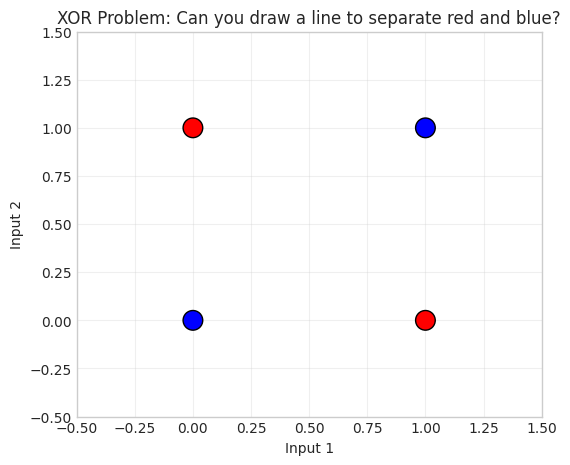


Notice: No straight line can separate the two classes!
This is why we need a neural network with a hidden layer.


In [266]:
# Create XOR dataset
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=np.float32)

y_xor = np.array([0, 1, 1, 0], dtype=np.float32)

# Visualize the XOR problem
plt.figure(figsize=(6, 5))
colors = ['blue' if y == 0 else 'red' for y in y_xor]
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=colors, s=200, edgecolors='black')
plt.xlabel('Input 1')
plt.ylabel('Input 2')
plt.title('XOR Problem: Can you draw a line to separate red and blue?')
plt.xlim(-0.5, 1.5)
plt.ylim(-0.5, 1.5)
plt.grid(True, alpha=0.3)
plt.show()

print("\nNotice: No straight line can separate the two classes!")
print("This is why we need a neural network with a hidden layer.")

In [267]:
def build_xor_network():
  return Sequential(
      Linear(2, 4, initialization='kaiming'),
      ReLU(),
      Linear(4, 1, initialization='kaiming'),
      Sigmoid()
  )

# Create the Network
model_xor = build_xor_network()

print(f"Total trainable parameters: {sum(p.data.size for p in model_xor.parameters())}")

Total trainable parameters: 17


In [268]:
# Setup
criterion = MSELoss()
optimizer = SGD(model_xor.parameters(), learning_rate=0.5)

In [269]:
# Convert data to Tensors
X_tensor = Tensor(X_xor)
y_tensor = Tensor(y_xor.reshape(-1, 1))

In [270]:
print("=== Training XOR ===")
print(f"Learning rate: {optimizer.lr}")
print(f"Loss function: MSE")
print(f"Epochs: 1000")

=== Training XOR ===
Learning rate: 0.5
Loss function: MSE
Epochs: 1000


In [271]:
# Training loop
losses = []
epochs = 1000

In [272]:
for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = model_xor(X_tensor)
    loss = criterion(predictions, y_tensor)
    loss.backward()
    optimizer.step()
    losses.append(loss.data.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1:4d}/{epochs}, Loss: {loss.data.item():.6f}")

# Get predictions
# with torch? No, with our framework.
predictions = model_xor(X_tensor)
pred_probs = predictions.data.flatten()
pred_binary = (pred_probs > 0.5).astype(int)

print("\n\nXOR Results")
print("Input  | Target | Prediction | Probability")
print("-------|--------|------------|------------")

for i in range(4):
    print(f"({X_xor[i,0]}, {X_xor[i,1]})  |  {int(y_xor[i])}      |    {pred_binary[i]}        |   {pred_probs[i]:.4f}")

# Calculate accuracy
accuracy = (pred_binary == y_xor).mean()
print(f"\nAccuracy: {accuracy:.2%}")
print("\nTraining complete!")

Epoch  100/1000, Loss: 0.174519
Epoch  200/1000, Loss: 0.154442
Epoch  300/1000, Loss: 0.025185
Epoch  400/1000, Loss: 0.009280
Epoch  500/1000, Loss: 0.005374
Epoch  600/1000, Loss: 0.003691
Epoch  700/1000, Loss: 0.002770
Epoch  800/1000, Loss: 0.002209
Epoch  900/1000, Loss: 0.001824
Epoch 1000/1000, Loss: 0.001545


XOR Results
Input  | Target | Prediction | Probability
-------|--------|------------|------------
(0.0, 0.0)  |  0      |    0        |   0.0487
(0.0, 1.0)  |  1      |    1        |   0.9734
(1.0, 0.0)  |  1      |    1        |   0.9733
(1.0, 1.0)  |  0      |    0        |   0.0488

Accuracy: 100.00%

Training complete!


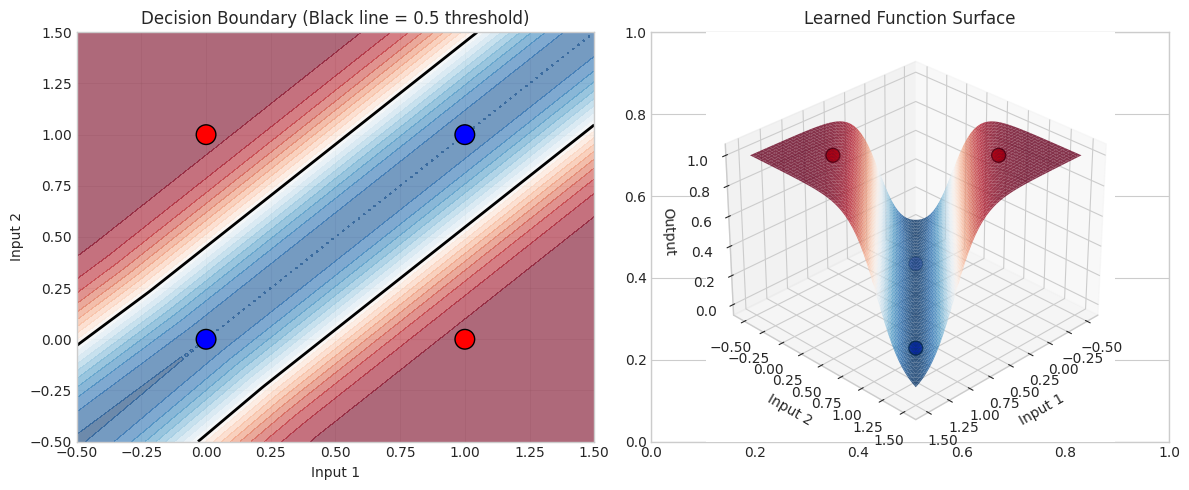

In [273]:
def plot_decision_boundary(model, X_data, y_data, resolution=100):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, resolution),
        np.linspace(y_min, y_max, resolution)
    )
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = Tensor(grid_points)
    preds = model(grid_tensor)
    Z = preds.data.reshape(xx.shape)
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].contourf(xx, yy, Z, levels=20, cmap='RdBu_r', alpha=0.6)
    axes[0].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)  # Decision boundary at 0.5
    colors = ['blue' if y == 0 else 'red' for y in y_data]
    axes[0].scatter(X_data[:, 0], X_data[:, 1], c=colors, s=200, edgecolors='black', zorder=5)
    axes[0].set_xlabel('Input 1')
    axes[0].set_ylabel('Input 2')
    axes[0].set_title('Decision Boundary (Black line = 0.5 threshold)')
    axes[0].set_xlim(-0.5, 1.5)
    axes[0].set_ylim(-0.5, 1.5)
    axes[0].grid(True, alpha=0.3)
    ax3d = fig.add_subplot(122, projection='3d')
    ax3d.plot_surface(xx, yy, Z, cmap='RdBu_r', alpha=0.8)
    ax3d.scatter(X_data[:, 0], X_data[:, 1], y_data, c=colors, s=100, edgecolors='black', zorder=5)
    ax3d.set_xlabel('Input 1')
    ax3d.set_ylabel('Input 2')
    ax3d.set_zlabel('Output')
    ax3d.set_title('Learned Function Surface')
    ax3d.view_init(elev=30, azim=45)

    plt.tight_layout()
    plt.show()


plot_decision_boundary(model_xor, X_xor, y_xor)